# Regresión Lineal para Predicción de LTV (Lifetime Value) a 24 Meses


## Objetivos de la sesión

* Comprender el concepto de LTV y su importancia como KPI financiero.
* Explorar cómo aplicar modelos de regresión lineal para predecir el LTV de clientes.
* Seleccionar y preparar variables relevantes para modelar el LTV usando Python.
* Interpretar la salida de un modelo de regresión y tomar decisiones sobre qué variables usar.

---

## Caso base: Tlacuachitos Express

**Contexto:**
Tlacuachitos Express es un servicio ficticio de entregas que desea predecir el valor que generará un cliente en los próximos 24 meses. El área de retención quiere utilizar este modelo para segmentar a los clientes y priorizar esfuerzos de fidelización.

## 1. ¿Qué es el LTV y por qué es importante?

* **Definición:** El Lifetime Value (LTV) es la suma de todas las compras realizadas por un cliente en sus primeros 24 meses.
* **Importancia:** Permite identificar clientes de alto valor, optimizar campañas y asignar mejor el presupuesto de marketing.

---

## 2. Exploración y limpieza de datos

* **Dataset realista**: Usaremos dos datasets:

  * `tlacuachitos_express_customers_data.csv`: Datos demográficos y cohortes de clientes
  * `tlacuachitos_express_transactions.csv`: Historial de transacciones

### Ejemplo de carga y exploración inicial de datos

In [2]:
import pandas as pd

# Cargar datasets
df_customers = pd.read_csv('data/tlacuachitos_express_customers_data.csv')
df_transactions = pd.read_csv('data/tlacuachitos_express_transactions.csv')

# Inspeccionar los primeros datos
df_customers.head()
df_transactions.head()

df_customers.info()
df_transactions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   CustomerID           1143 non-null   int64  
 1   Age                  1143 non-null   int64  
 2   Income               1143 non-null   float64
 3   Tenure               1143 non-null   int64  
 4   Education            1143 non-null   object 
 5   Industry             1143 non-null   object 
 6   Geographic Location  1143 non-null   object 
 7   Cohort               1143 non-null   object 
dtypes: float64(1), int64(3), object(4)
memory usage: 71.6+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31552 entries, 0 to 31551
Data columns (total 3 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         31552 non-null  int64  
 1   TransactionDate    31552 non-null  object 
 2   TransactionAmount  31552 n

### Limpieza de variables clave

* Conversión de fechas
* Verificación de nulos y outliers

In [3]:
df_transactions['TransactionDate'] = pd.to_datetime(df_transactions['TransactionDate'])
df_customers['Cohort'] = pd.to_datetime(df_customers['Cohort'])

# Definir la fecha de corte para análisis
snapshot_date = df_transactions['TransactionDate'].max()

# Calcular tenure (meses desde registro hasta snapshot)
df_customers['customer_tenure'] = ((snapshot_date.year - df_customers['Cohort'].dt.year)*12 +
                                   (snapshot_date.month - df_customers['Cohort'].dt.month))

df_customers.head(3)

,CustomerID,Age,Income,Tenure,Education,Industry,Geographic Location,Cohort,customer_tenure
0,1,56,52752.677346,3,Master,Technology,Europe,2023-08-31,19
1,2,69,55297.364348,6,Bachelor,Technology,South America,2021-08-31,43
2,3,46,57978.753383,3,Bachelor,Finance,Europe,2019-05-31,70


---

## 3. Cálculo del LTV a 24 meses

* Solo sumamos las transacciones realizadas por cada cliente dentro de sus primeros 24 meses.

In [4]:
df_master = df_transactions.merge(df_customers, on='CustomerID')
df_master['customer_tenure_on_transaction'] = (
    (df_master['TransactionDate'].dt.year - df_master['Cohort'].dt.year)*12 +
    (df_master['TransactionDate'].dt.month - df_master['Cohort'].dt.month)
)

cltv_24_months = df_master[
    (df_master['customer_tenure_on_transaction'] <= 24)
].groupby('CustomerID')['TransactionAmount'].sum().reset_index()
cltv_24_months.rename(columns={'TransactionAmount': 'LTV'}, inplace=True)
cltv_24_months.head()

,CustomerID,LTV
0,1,10433.668665
1,2,11276.581901
2,3,5084.632444
3,4,3037.917187
4,5,11677.948404


---

## 4. Ingeniería y selección de variables (feature engineering)

* Ejemplo de variables:

  * **Num transacciones** en 24 meses
  * **Monto promedio**
  * Edad, educación, industria, ubicación, ingresos

### Ejemplo de codificación y combinación de variables

In [5]:
# Variables categóricas a dummies
df_encoded = pd.get_dummies(df_customers, columns=['Education', 'Industry', 'Geographic Location'], drop_first=False, dtype=int)

# Unir con LTV
features_for_model = cltv_24_months.merge(df_encoded, on='CustomerID')
features_for_model['num_transactions'] = df_master[df_master['customer_tenure_on_transaction'] <= 24].groupby('CustomerID').size().values
features_for_model.head()

,CustomerID,LTV,Age,Income,Tenure,Cohort,customer_tenure,Education_Bachelor,Education_High School,Education_Master,...,Industry_Entertainment,Industry_Finance,Industry_Healthcare,Industry_Technology,Geographic Location_Asia,Geographic Location_Australia,Geographic Location_Europe,Geographic Location_North America,Geographic Location_South America,num_transactions
0,1,10433.668665,56,52752.677346,3,2023-08-31,19,0,0,1,...,0,0,0,1,0,0,1,0,0,29
1,2,11276.581901,69,55297.364348,6,2021-08-31,43,1,0,0,...,0,0,0,1,0,0,0,0,1,31
2,3,5084.632444,46,57978.753383,3,2019-05-31,70,1,0,0,...,0,1,0,0,0,0,1,0,0,21
3,4,3037.917187,32,60445.266900,3,2021-02-28,49,0,1,0,...,0,0,0,0,0,0,0,0,1,13
4,5,11677.948404,60,57741.870929,5,2018-10-31,77,1,0,0,...,1,0,0,0,1,0,0,0,0,32


Las variables númericas que usaremos son el ingreso y la edad. Hay que estandarizarlas.

In [19]:
from sklearn.preprocessing import StandardScaler

numerical_features = ['Income', 'Age']

scaler = StandardScaler()

# Estandariza los features numéricos, dejando las dummies igual
features_for_model[numerical_features] = scaler.fit_transform(features_for_model[numerical_features])

features_for_model[numerical_features].head()


,Income,Age
0,0.121621,0.824019
1,0.286515,1.688471
2,0.460267,0.159056
3,0.620095,-0.771892
4,0.444917,1.090004


---

## 5. Selección y ajuste del modelo de regresión lineal

* Usaremos `statsmodels` para la regresión lineal y un método de selección de variables basado en p-value.

### Ajuste inicial

In [20]:
import statsmodels.api as sm

X = features_for_model.drop(['CustomerID', 'LTV', 'Cohort', 'num_transactions', 'Tenure', 'customer_tenure'], axis=1)
y = features_for_model['LTV']
X = sm.add_constant(X)

model = sm.OLS(y, X)
results = model.fit()
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                    LTV   R-squared:                       0.607
Model:                            OLS   Adj. R-squared:                  0.602
Method:                 Least Squares   F-statistic:                     133.9
Date:                Thu, 07 Aug 2025   Prob (F-statistic):          6.92e-218
Time:                        13:56:48   Log-Likelihood:                -10314.
No. Observations:                1143   AIC:                         2.066e+04
Df Residuals:                    1129   BIC:                         2.073e+04
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
                                        coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------
const 

### Selección de variables relevantes (p-value < 0.05)

In [21]:
# Selección iterativa por p-value
def stepwise_selection(X, y, threshold_out=0.05):
    while True:
        model = sm.OLS(y, X).fit()
        max_pval = model.pvalues.drop('const').max()
        if max_pval > threshold_out:
            worst_feature = model.pvalues.drop('const').idxmax()
            X = X.drop(worst_feature, axis=1)
        else:
            break
    return X, model

X_selected, final_model = stepwise_selection(X, y)
print(final_model.summary())

                            OLS Regression Results                            
Dep. Variable:                    LTV   R-squared:                       0.605
Model:                            OLS   Adj. R-squared:                  0.601
Method:                 Least Squares   F-statistic:                     144.5
Date:                Thu, 07 Aug 2025   Prob (F-statistic):          2.65e-218
Time:                        13:56:56   Log-Likelihood:                -10316.
No. Observations:                1143   AIC:                         2.066e+04
Df Residuals:                    1130   BIC:                         2.072e+04
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                                        coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------
const 

---

## 6. Interpretación de resultados

* ¿Qué variables son estadísticamente significativas?
* ¿Qué variables aumentan o disminuyen el LTV?
* ¿Cómo se interpreta el R²?

### Ejemplo de visualización de importancia de coeficientes

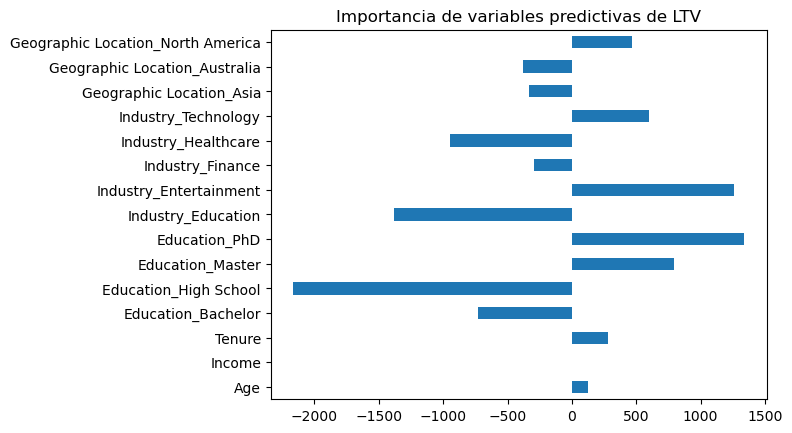

In [8]:
import matplotlib.pyplot as plt
coefs = final_model.params[1:]
coefs.plot(kind='barh')
plt.title('Importancia de variables predictivas de LTV')
plt.show()

---

## 7. Cierre y reflexiones para la próxima clase

* Elige las variables que explicarás a tu equipo directivo y por qué.
* ¿Qué variables NO incluyes y por qué?

---

## Para la siguiente clase

* Piensa cómo usar el modelo para predecir el LTV de un nuevo cliente.
* ¿Cómo priorizarías clientes si tuvieras presupuesto limitado para retención?

---

## Referencias

* [Documentación oficial de statsmodels - Regresión OLS](https://www.statsmodels.org/stable/generated/statsmodels.regression.linear_model.OLS.html)
* [Documentación pandas](https://pandas.pydata.org/pandas-docs/stable/)
* [Documentación scikit-learn - Feature Engineering](https://scikit-learn.org/stable/modules/preprocessing.html)
